In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np
from scipy.sparse import csr_matrix
import csv
import random
import pickle

## 按照GlOVE的方式embedding

### 读取数据流文件

In [1]:
import pandas as pd

# 加载csv文件
df = pd.read_csv('./archive/dataset_TSMC2014_NYC.csv')

# 查看前5条记录
df


,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012
...,...,...,...,...,...,...,...,...
227423,688,3fd66200f964a52000e71ee3,4bf58dd8d48988d1e7931735,Music Venue,40.733596,-74.003139,-300,Sat Feb 16 02:29:11 +0000 2013
227424,560,4bca32ff0687ef3be789dbcc,4bf58dd8d48988d16c941735,Burger Joint,40.745719,-73.993720,-300,Sat Feb 16 02:31:35 +0000 2013
227425,945,50a77716e4b0b5a9492f6f56,4bf58dd8d48988d103941735,Home (private),40.854365,-73.883070,-300,Sat Feb 16 02:33:16 +0000 2013
227426,671,4514efe0f964a520e7391fe3,4bf58dd8d48988d11d941735,Bar,40.735981,-74.029309,-300,Sat Feb 16 02:34:31 +0000 2013


In [2]:
unique_values = df['venueCategoryId'].nunique()

# 打印结果
print('不重复值的数量:', unique_values)

不重复值的数量: 400


### 类别id去重

In [3]:
#假设类别可以全信息获得，因此不采用截取等方式
veneucatdata =df[["venueCategoryId","venueCategory"]].drop_duplicates()
veneucatdata = veneucatdata.reset_index(drop=True)
veneucatdata = veneucatdata.reset_index().rename(columns={"index":"itemId"})
veneucatdata

,itemId,venueCategoryId,venueCategory
0,0,4bf58dd8d48988d127951735,Arts & Crafts Store
1,1,4bf58dd8d48988d1df941735,Bridge
2,2,4bf58dd8d48988d103941735,Home (private)
3,3,4bf58dd8d48988d104941735,Medical Center
4,4,4bf58dd8d48988d1cb941735,Food Truck
...,...,...,...
395,395,5032897c91d4c4b30a586d69,Pet Service
396,396,4f04b08c2fb6e1c99f3db0bd,Miscellaneous Shop
397,397,4eb1c0ed3b7b52c0e1adc2ea,Ski Area
398,398,5032856091d4c4b30a586d63,Office


### 送入glove根据类别名求向量

In [11]:
import torchtext
import re
import numpy as np
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize


embedding = torchtext.vocab.GloVe(name='840B', dim=300)
category_embedding = np.zeros(shape=(veneucatdata.shape[0], 300), dtype=np.float32)
for i, text in enumerate(veneucatdata['venueCategory']):
    clean_text = re.sub(r'[^\w\s]','',text)
    tokens = word_tokenize(clean_text)
    print(tokens)
    category_embedding[i, :] = embedding.get_vecs_by_tokens(tokens).numpy().mean(axis=0)
category_df = pd.DataFrame(category_embedding)
category_df

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\89660\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['Arts', 'Crafts', 'Store']
['Bridge']
['Home', 'private']
['Medical', 'Center']
['Food', 'Truck']
['Food', 'Drink', 'Shop']
['Coffee', 'Shop']
['Bus', 'Station']
['Bank']
['Gastropub']
['Electronics', 'Store']
['Mobile', 'Phone', 'Shop']
['Café']
['Automotive', 'Shop']
['Restaurant']
['American', 'Restaurant']
['Government', 'Building']
['Airport']
['Ferry']
['Office']
['Other', 'Great', 'Outdoors']
['Building']
['Mexican', 'Restaurant']
['Music', 'Venue']
['Subway']
['Student', 'Center']
['Park']
['Road']
['Burger', 'Joint']
['Sporting', 'Goods', 'Shop']
['Pizza', 'Place']
['Jewelry', 'Store']
['Sandwich', 'Place']
['Clothing', 'Store']
['Neighborhood']
['Medical', 'Center']
['Medical', 'Center']
['Bus', 'Station']
['Ice', 'Cream', 'Shop']
['Soup', 'Place']
['College', 'Academic', 'Building']
['Department', 'Store']
['Playground']
['Tattoo', 'Parlor']
['Mall']
['Deli', 'Bodega']
['College', 'Academic', 'Building']
['University']
['Diner']
['Music', 'Store']
['Light', 'Rail']
['Salon'

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,0.222397,0.250557,0.018645,0.277347,-0.144500,-0.072369,-0.159967,0.268785,0.061341,0.855680,...,-0.374596,-0.033471,0.072380,0.068150,-0.082918,-0.200378,0.007124,-0.158429,0.049896,0.819390
1,-0.196310,0.215140,-0.411350,-0.216870,0.493240,0.098806,-0.550380,0.327190,0.127570,1.615600,...,-0.640060,0.026749,0.161900,0.097234,-0.061024,-0.319000,-0.062980,-0.458960,-0.166210,-0.053188
2,0.134430,-0.103765,-0.053090,0.034235,0.147555,-0.204045,0.165286,-0.500670,0.334210,2.002435,...,0.018905,-0.055325,0.019353,-0.077329,0.094947,0.094775,-0.043160,-0.453420,0.321250,0.113265
3,-0.065344,-0.154875,0.057800,0.219950,-0.084860,-0.311045,-0.504460,-0.196035,0.241075,2.302150,...,0.532725,0.108802,0.133628,-0.570365,0.289825,-0.123545,-0.156247,0.403780,-0.072915,0.470620
4,-0.243645,0.265950,0.248791,-0.113132,0.233322,0.559195,-0.176789,-0.018504,0.191690,0.761360,...,-0.292490,0.005960,0.463070,-0.294230,-0.265860,-0.393910,0.278370,-0.191629,0.396170,0.202112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,-0.304600,0.266800,0.006700,-0.276614,0.162778,-0.002715,0.153474,-0.219867,-0.158955,1.203885,...,-0.274525,-0.087646,0.174526,-0.022835,0.071900,0.185175,0.056747,0.088425,0.246150,0.060985
396,0.300035,0.047700,0.096723,0.307125,-0.024090,0.019250,0.120355,0.087030,0.378170,-0.099815,...,-0.638005,-0.068921,0.349487,-0.014305,0.129129,-0.412550,0.416685,-0.267060,0.042450,0.290087
397,0.522100,-0.043345,-0.137695,-0.144809,0.435605,0.152752,0.345724,0.047240,-0.075512,1.146255,...,-0.286762,0.356110,-0.000605,-0.416580,0.037720,-0.158935,-0.169221,0.190320,0.369155,0.119493
398,-0.361030,-0.589770,-0.201960,0.057930,-0.235760,-0.109500,-0.131660,-0.614300,0.468680,1.970900,...,0.416870,0.353100,1.186100,0.299360,-0.238980,0.078941,0.361210,-0.157040,-0.110790,-0.311850


### 给列名

In [12]:
category_df.columns = ["i"+str(i) for i in range(300)]
category_df = category_df.reset_index().rename(columns={"index":"itemId"})
category_df

,itemId,i0,i1,i2,i3,i4,i5,i6,i7,i8,...,i290,i291,i292,i293,i294,i295,i296,i297,i298,i299
0,0,0.222397,0.250557,0.018645,0.277347,-0.144500,-0.072369,-0.159967,0.268785,0.061341,...,-0.374596,-0.033471,0.072380,0.068150,-0.082918,-0.200378,0.007124,-0.158429,0.049896,0.819390
1,1,-0.196310,0.215140,-0.411350,-0.216870,0.493240,0.098806,-0.550380,0.327190,0.127570,...,-0.640060,0.026749,0.161900,0.097234,-0.061024,-0.319000,-0.062980,-0.458960,-0.166210,-0.053188
2,2,0.134430,-0.103765,-0.053090,0.034235,0.147555,-0.204045,0.165286,-0.500670,0.334210,...,0.018905,-0.055325,0.019353,-0.077329,0.094947,0.094775,-0.043160,-0.453420,0.321250,0.113265
3,3,-0.065344,-0.154875,0.057800,0.219950,-0.084860,-0.311045,-0.504460,-0.196035,0.241075,...,0.532725,0.108802,0.133628,-0.570365,0.289825,-0.123545,-0.156247,0.403780,-0.072915,0.470620
4,4,-0.243645,0.265950,0.248791,-0.113132,0.233322,0.559195,-0.176789,-0.018504,0.191690,...,-0.292490,0.005960,0.463070,-0.294230,-0.265860,-0.393910,0.278370,-0.191629,0.396170,0.202112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,-0.304600,0.266800,0.006700,-0.276614,0.162778,-0.002715,0.153474,-0.219867,-0.158955,...,-0.274525,-0.087646,0.174526,-0.022835,0.071900,0.185175,0.056747,0.088425,0.246150,0.060985
396,396,0.300035,0.047700,0.096723,0.307125,-0.024090,0.019250,0.120355,0.087030,0.378170,...,-0.638005,-0.068921,0.349487,-0.014305,0.129129,-0.412550,0.416685,-0.267060,0.042450,0.290087
397,397,0.522100,-0.043345,-0.137695,-0.144809,0.435605,0.152752,0.345724,0.047240,-0.075512,...,-0.286762,0.356110,-0.000605,-0.416580,0.037720,-0.158935,-0.169221,0.190320,0.369155,0.119493
398,398,-0.361030,-0.589770,-0.201960,0.057930,-0.235760,-0.109500,-0.131660,-0.614300,0.468680,...,0.416870,0.353100,1.186100,0.299360,-0.238980,0.078941,0.361210,-0.157040,-0.110790,-0.311850


### 将去重后的类别id 和 embedding拼接

In [13]:

veneue_featuer = pd.merge(veneucatdata,category_df, on='itemId', how='inner' )
veneue_featuer


,itemId,venueCategoryId,venueCategory,i0,i1,i2,i3,i4,i5,i6,...,i290,i291,i292,i293,i294,i295,i296,i297,i298,i299
0,0,4bf58dd8d48988d127951735,Arts & Crafts Store,0.222397,0.250557,0.018645,0.277347,-0.144500,-0.072369,-0.159967,...,-0.374596,-0.033471,0.072380,0.068150,-0.082918,-0.200378,0.007124,-0.158429,0.049896,0.819390
1,1,4bf58dd8d48988d1df941735,Bridge,-0.196310,0.215140,-0.411350,-0.216870,0.493240,0.098806,-0.550380,...,-0.640060,0.026749,0.161900,0.097234,-0.061024,-0.319000,-0.062980,-0.458960,-0.166210,-0.053188
2,2,4bf58dd8d48988d103941735,Home (private),0.134430,-0.103765,-0.053090,0.034235,0.147555,-0.204045,0.165286,...,0.018905,-0.055325,0.019353,-0.077329,0.094947,0.094775,-0.043160,-0.453420,0.321250,0.113265
3,3,4bf58dd8d48988d104941735,Medical Center,-0.065344,-0.154875,0.057800,0.219950,-0.084860,-0.311045,-0.504460,...,0.532725,0.108802,0.133628,-0.570365,0.289825,-0.123545,-0.156247,0.403780,-0.072915,0.470620
4,4,4bf58dd8d48988d1cb941735,Food Truck,-0.243645,0.265950,0.248791,-0.113132,0.233322,0.559195,-0.176789,...,-0.292490,0.005960,0.463070,-0.294230,-0.265860,-0.393910,0.278370,-0.191629,0.396170,0.202112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,5032897c91d4c4b30a586d69,Pet Service,-0.304600,0.266800,0.006700,-0.276614,0.162778,-0.002715,0.153474,...,-0.274525,-0.087646,0.174526,-0.022835,0.071900,0.185175,0.056747,0.088425,0.246150,0.060985
396,396,4f04b08c2fb6e1c99f3db0bd,Miscellaneous Shop,0.300035,0.047700,0.096723,0.307125,-0.024090,0.019250,0.120355,...,-0.638005,-0.068921,0.349487,-0.014305,0.129129,-0.412550,0.416685,-0.267060,0.042450,0.290087
397,397,4eb1c0ed3b7b52c0e1adc2ea,Ski Area,0.522100,-0.043345,-0.137695,-0.144809,0.435605,0.152752,0.345724,...,-0.286762,0.356110,-0.000605,-0.416580,0.037720,-0.158935,-0.169221,0.190320,0.369155,0.119493
398,398,5032856091d4c4b30a586d63,Office,-0.361030,-0.589770,-0.201960,0.057930,-0.235760,-0.109500,-0.131660,...,0.416870,0.353100,1.186100,0.299360,-0.238980,0.078941,0.361210,-0.157040,-0.110790,-0.311850


In [14]:
import json
cat_id_map_dict={}
for index, row in veneue_featuer.iterrows():
        key = str(row[1])
        value = int(row[0])
        cat_id_map_dict[key] = value

##不写入
# with open('./NYC/cat_id_map_dict.json', 'w') as f:
#      json.dump(cat_id_map_dict,f)
# cat_id_map_dict


# 将venue id 映射 为新的 int 型id，创建 events时要用到


### PCA降维

In [18]:
from sklearn.decomposition import PCA
pca = PCA(n_components=25)
item_df_for_pca = category_df[["i"+str(i) for i in range(300)]]
pca.fit(item_df_for_pca)
item_pca = pca.transform(item_df_for_pca)
item_pca

array([[-6.40834689e-01, -2.04996800e+00,  1.10252023e-01, ...,
         2.29402542e-01, -5.56686163e-01,  2.00210318e-01],
       [-7.21045613e-01,  1.25023627e+00,  1.09082675e+00, ...,
        -8.71828198e-02, -8.32038641e-01, -9.45552252e-04],
       [-7.27604926e-01, -3.23359966e-01,  4.60064374e-02, ...,
        -7.16507792e-01,  1.76226035e-01, -2.40690127e-01],
       ...,
       [-4.60960031e-01,  2.57703096e-01,  1.41565371e+00, ...,
        -2.29884878e-01, -7.13782489e-01,  2.83281386e-01],
       [-1.88294494e+00, -7.04887509e-01, -9.79490399e-01, ...,
         1.07979506e-01, -1.44433215e-01,  3.10899675e-01],
       [-3.45140517e-01, -1.14182138e+00,  7.15410590e-01, ...,
         2.94198602e-01, -1.41246662e-01,  5.53019583e-01]], dtype=float32)

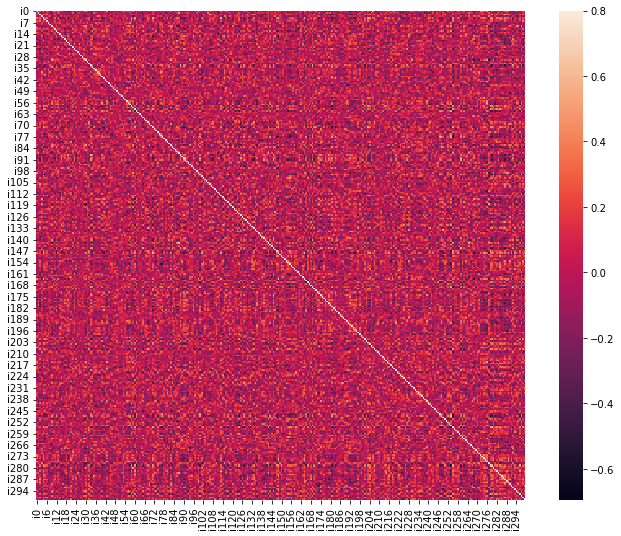

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
corrmat = item_df_for_pca.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)
plt.show()

<AxesSubplot:>

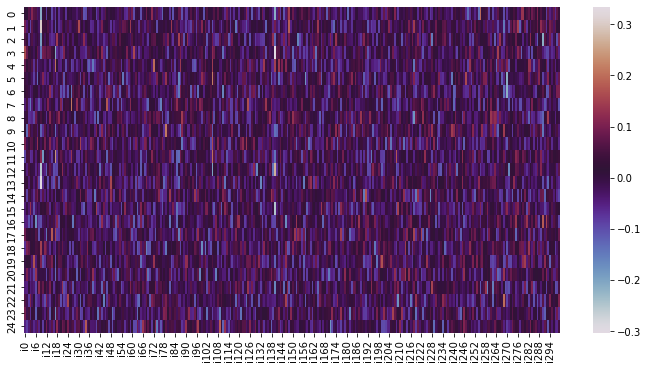

In [26]:
map= pd.DataFrame(pca.components_,columns=item_df_for_pca.columns)
plt.figure(figsize=(12,6))
sns.heatmap(map,cmap='twilight')

In [11]:
# new_item_df = pd.concat([cols["catmapid"], pd.DataFrame(item_pca)], axis=1)
item_pca_df = pd.DataFrame(item_pca)
index_item_pca_df = item_pca_df.reset_index().rename(columns={"index":"itemId"})
index_item_pca_df.columns = ["iid"] + ["i"+str(i) for i in range(30)]
index_item_pca_df
index_item_pca_df


,iid,i0,i1,i2,i3,i4,i5,i6,i7,i8,...,i20,i21,i22,i23,i24,i25,i26,i27,i28,i29
0,0,0.657974,-2.922702,1.093436,-0.321638,0.566710,0.618241,0.577463,0.174613,1.026980,...,0.372413,0.250498,-0.549303,0.601572,0.645974,0.216180,0.203721,-0.131751,-0.684646,-0.332751
1,1,1.486469,0.022940,-0.345761,0.238843,-1.555807,-0.367729,-0.594543,-0.196363,-0.041606,...,0.391831,0.442060,-0.556623,-0.555721,0.128485,0.308736,0.075393,0.720173,0.491636,-0.754876
2,2,0.460253,-2.101492,1.120530,-0.629913,0.076334,-0.134147,-0.052177,0.817060,0.883032,...,-0.362786,-0.125030,0.666046,0.167738,-0.191677,-0.146905,-0.011669,-0.037223,-0.154464,-0.279693
3,3,1.455816,-2.209945,-0.122776,0.022961,-0.345108,-0.137071,0.542443,0.298330,0.300342,...,-0.019057,-0.421162,0.155108,-0.019523,0.568312,0.143099,-0.305424,-0.175460,0.072331,0.112779
4,4,-1.903222,-0.123878,-0.993108,-1.355554,-0.067508,-1.247147,-0.362248,-0.502985,-0.038662,...,1.046179,-0.574999,-0.620744,-0.118753,-0.458025,-0.196459,0.024977,1.253843,-0.161231,0.192673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,3.373396,0.725187,-0.636794,0.140131,-1.497879,-0.133812,0.216209,0.785519,0.313301,...,-0.207440,-0.069082,-0.126574,-0.048025,-0.100303,-0.177469,0.019176,1.008755,-0.150492,0.861524
381,381,-0.773647,-0.239312,-0.065544,-1.108073,-0.131478,-0.306484,0.233120,-0.661242,-0.299684,...,0.281003,0.030973,-0.685727,-0.110111,0.130980,-0.486787,-0.330197,-0.303068,0.644883,-0.309509
382,382,-2.569423,0.535074,-1.222084,-0.691747,1.139475,0.807539,-0.302311,2.841971,-1.026907,...,-0.451124,0.076153,0.040269,-0.032924,-0.276563,0.253917,0.227430,0.232120,-0.075238,0.058602
383,383,-1.935301,2.692880,1.795974,4.281910,-0.842276,-1.322124,0.727193,1.055992,2.399717,...,-0.193665,0.129745,0.244484,-0.104036,-0.190591,-0.438039,0.101841,-0.020097,-0.301927,-0.220148


In [87]:
index_item_pca_df.to_csv('./TKY/POI_Glove_FeatureVectors.csv', sep=' ', index=False, header=True)
